In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

class EpsilonGreedyBandit:
    def __init__(self, n_arms, epsilon=0.1):
        """
        Initialize the Multi-Armed Bandit

        Parameters:
        - n_arms: Number of arms/ad slots
        - epsilon: Exploration rate (0.1 = 10% exploration)
        """
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.counts = np.zeros(n_arms)  # Number of times each arm was pulled
        self.values = np.zeros(n_arms)  # Estimated CTR for each arm
        self.arm_names = ['Top Banner', 'Sidebar', 'Footer', 'Pop-up']

    def select_arm(self):
        """
        Select an arm using epsilon-greedy strategy
        """
        if random.random() < self.epsilon:
            # Exploration: choose random arm
            return random.randint(0, self.n_arms - 1)
        else:
            # Exploitation: choose arm with highest estimated CTR
            return np.argmax(self.values)

    def update(self, chosen_arm, reward):
        """
        Update the estimated CTR for the chosen arm

        Parameters:
        - chosen_arm: The arm that was selected
        - reward: 1 if clicked, 0 if not clicked
        """
        self.counts[chosen_arm] += 1
        n = self.counts[chosen_arm]

        # Update the average CTR incrementally
        current_value = self.values[chosen_arm]
        self.values[chosen_arm] = ((n - 1) * current_value + reward) / n

    def get_stats(self):
        """Return current statistics"""
        return {
            'counts': self.counts.copy(),
            'values': self.values.copy(),
            'total_impressions': np.sum(self.counts),
            'total_clicks': np.sum(self.values * self.counts)
        }

Starting Multi-Armed Bandit Simulation for Ad Slots
True CTRs: {'Top Banner': 0.08, 'Sidebar': 0.12, 'Footer': 0.05, 'Pop-up': 0.15}

Simulation Complete!

Final Results:
------------------------------
Top Banner  : Impressions: 42   | Clicks: 3   | Estimated CTR: 0.071 | Actual CTR: 0.071 | True CTR: 0.080
Sidebar     : Impressions: 26   | Clicks: 2   | Estimated CTR: 0.077 | Actual CTR: 0.077 | True CTR: 0.120
Footer      : Impressions: 40   | Clicks: 4   | Estimated CTR: 0.100 | Actual CTR: 0.100 | True CTR: 0.050
Pop-up      : Impressions: 892  | Clicks: 157 | Estimated CTR: 0.176 | Actual CTR: 0.176 | True CTR: 0.150

Total Impressions: 1000
Total Clicks: 166
Overall CTR: 0.166


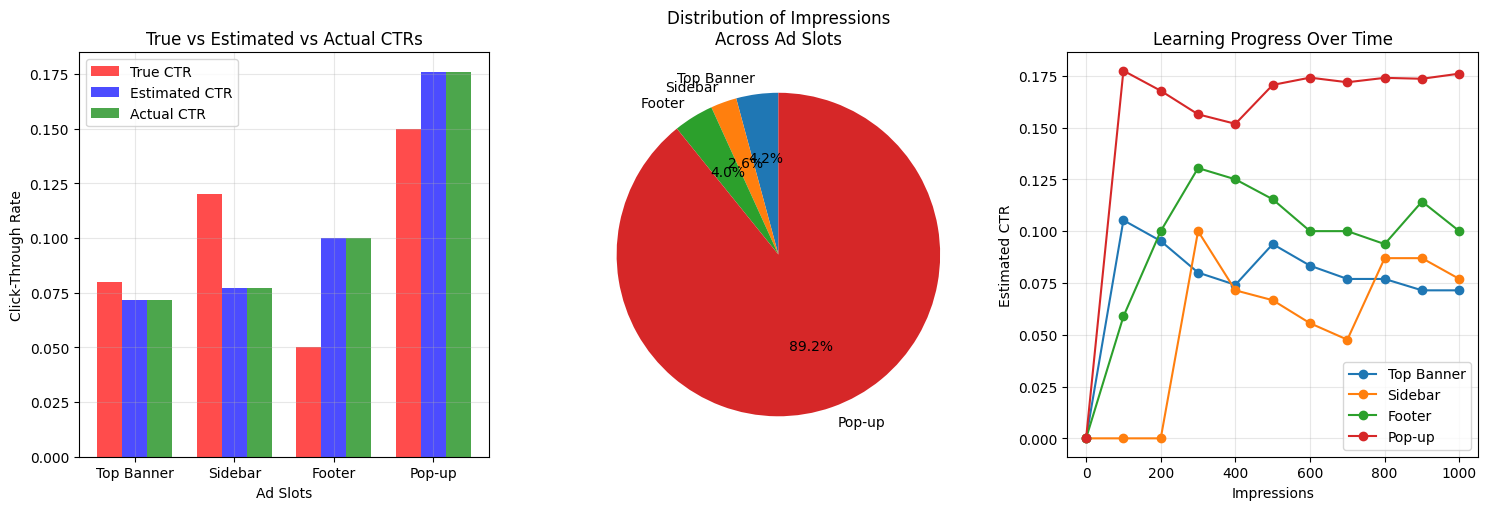


Performance Analysis:
------------------------------
Best performing ad slot: Pop-up (True CTR: 0.150)
Optimal strategy clicks: 150.0
Actual clicks: 166
Regret (lost clicks): -16.0
Efficiency: 110.7%


In [2]:
def simulate_click(ad_slot, true_ctrs):
    """
    Simulate whether a user clicks on an ad in the given slot

    Parameters:
    - ad_slot: The ad slot being shown
    - true_ctrs: True CTRs for each ad slot

    Returns:
    - 1 if clicked, 0 otherwise
    """
    # Simulate click based on true CTR
    return 1 if random.random() < true_ctrs[ad_slot] else 0

# True CTRs for each ad slot (unknown in real scenario)
true_ctrs = [0.08, 0.12, 0.05, 0.15]  # [Top Banner, Sidebar, Footer, Pop-up]

# Initialize the bandit
bandit = EpsilonGreedyBandit(n_arms=4, epsilon=0.1)

# Track results for analysis
results = {
    'clicks_per_arm': [0, 0, 0, 0],
    'impressions_per_arm': [0, 0, 0, 0],
    'ctr_history': [],
    'arm_selections': []
}

print("Starting Multi-Armed Bandit Simulation for Ad Slots")
print("=" * 50)
print(f"True CTRs: {dict(zip(bandit.arm_names, true_ctrs))}")
print()

# Run simulation for 1000 impressions
n_impressions = 1000

for impression in range(n_impressions):
    # Select an ad slot
    chosen_arm = bandit.select_arm()

    # Simulate user click
    click = simulate_click(chosen_arm, true_ctrs)

    # Update the bandit
    bandit.update(chosen_arm, click)

    # Track results
    results['impressions_per_arm'][chosen_arm] += 1
    if click == 1:
        results['clicks_per_arm'][chosen_arm] += 1

    # Store history every 100 impressions
    if impression % 100 == 0 or impression == n_impressions - 1:
        current_ctrs = [results['clicks_per_arm'][i] / max(1, results['impressions_per_arm'][i])
                       for i in range(4)]
        results['ctr_history'].append(current_ctrs.copy())
        results['arm_selections'].append(results['impressions_per_arm'].copy())

# Display final results
print("Simulation Complete!")
print("=" * 50)
print("\nFinal Results:")
print("-" * 30)

stats = bandit.get_stats()
for i in range(4):
    actual_ctr = results['clicks_per_arm'][i] / max(1, results['impressions_per_arm'][i])
    print(f"{bandit.arm_names[i]:<12}: "
          f"Impressions: {results['impressions_per_arm'][i]:<4} | "
          f"Clicks: {results['clicks_per_arm'][i]:<3} | "
          f"Estimated CTR: {bandit.values[i]:.3f} | "
          f"Actual CTR: {actual_ctr:.3f} | "
          f"True CTR: {true_ctrs[i]:.3f}")

print(f"\nTotal Impressions: {n_impressions}")
print(f"Total Clicks: {sum(results['clicks_per_arm'])}")
print(f"Overall CTR: {sum(results['clicks_per_arm']) / n_impressions:.3f}")

# Visualization
plt.figure(figsize=(15, 5))

# Plot 1: Estimated vs True CTRs
plt.subplot(1, 3, 1)
x_pos = np.arange(len(bandit.arm_names))
width = 0.25

plt.bar(x_pos - width, true_ctrs, width, label='True CTR', alpha=0.7, color='red')
plt.bar(x_pos, bandit.values, width, label='Estimated CTR', alpha=0.7, color='blue')
plt.bar(x_pos + width, [results['clicks_per_arm'][i] / max(1, results['impressions_per_arm'][i])
                       for i in range(4)], width, label='Actual CTR', alpha=0.7, color='green')

plt.xlabel('Ad Slots')
plt.ylabel('Click-Through Rate')
plt.title('True vs Estimated vs Actual CTRs')
plt.xticks(x_pos, bandit.arm_names)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Impressions Distribution
plt.subplot(1, 3, 2)
plt.pie(results['impressions_per_arm'], labels=bandit.arm_names, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Impressions\nAcross Ad Slots')

# Plot 3: Learning Progress
plt.subplot(1, 3, 3)
history_points = len(results['ctr_history'])
x_vals = [i * (n_impressions // (history_points - 1)) for i in range(history_points)]

for i in range(4):
    ctr_progress = [results['ctr_history'][j][i] for j in range(history_points)]
    plt.plot(x_vals, ctr_progress, label=bandit.arm_names[i], marker='o')

plt.xlabel('Impressions')
plt.ylabel('Estimated CTR')
plt.title('Learning Progress Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Performance Analysis
print("\nPerformance Analysis:")
print("-" * 30)
best_arm = np.argmax(true_ctrs)
print(f"Best performing ad slot: {bandit.arm_names[best_arm]} (True CTR: {true_ctrs[best_arm]:.3f})")

# Calculate regret (clicks lost compared to optimal strategy)
optimal_clicks = n_impressions * true_ctrs[best_arm]
actual_clicks = sum(results['clicks_per_arm'])
regret = optimal_clicks - actual_clicks

print(f"Optimal strategy clicks: {optimal_clicks:.1f}")
print(f"Actual clicks: {actual_clicks}")
print(f"Regret (lost clicks): {regret:.1f}")
print(f"Efficiency: {actual_clicks / optimal_clicks * 100:.1f}%")